In [1]:
url1 = "https://eur-lex.europa.eu/legal-content/EN/TXT/?uri=CELEX:32023R2631" #only modified by block
url2 = "https://eur-lex.europa.eu/legal-content/EN/TXT/?uri=consil:ST_13940_2023_ADD_2_REV_1" #no modifies or modified by block
url3 = "https://eur-lex.europa.eu/legal-content/EN/TXT/?uri=CELEX:32019R2019" #both modifies or modified by block
url4 ="https://eur-lex.europa.eu/legal-content/EN/TXT/?uri=CELEX:32009R0643"

collect all the urls:

#### if there are a lot of runtime error, you need to change the delay argument from the _load_page(delay=) and try higher numbers
For example, if delay is 2 in the load_page(), there are more errors like runtime error and the code will try more attempts and it become super slower. Increasingly, more timeout can make the websites think it is a human clicking not a robot.

In [ ]:
# it takes 4m to get the full graph from the modifiedby talbe in the url3
from graph_builder import Modifiedby
mb = Modifiedby("https://eur-lex.europa.eu/legal-content/EN/TXT/?uri=CELEX:32023R2631")
urls = mb.collect_all_urls()
graph = mb.generate_full_graph(urls, visualize = True)

In [ ]:
print(mb.failed_urls)

https://eur-lex.europa.eu/legal-content/EN/TXT/?uri=CELEX:32009R0643
[{'Relation': 'Repeal', 'Act': '31996L0057', 'Comment': '', 'Subdivision concerned': '', 'From': '', 'To': ''}, {'Relation': 'Implicit repeal', 'Act': '32008L0028', 'Comment': 'Partial repeal', 'Subdivision concerned': 'article 3', 'From': '01/07/2010', 'To': ''}]
DiGraph with 0 nodes and 0 edges
['https://eur-lex.europa.eu/legal-content/EN/TXT/?uri=CELEX:31996L0057', 'https://eur-lex.europa.eu/legal-content/EN/TXT/?uri=CELEX:32008L0028']
32009R0643


Crawling URLs: 10it [00:45,  4.54s/it]



Total URLs collected: 10


Building graph: 100%|██████████| 10/10 [01:00<00:00,  6.01s/it]


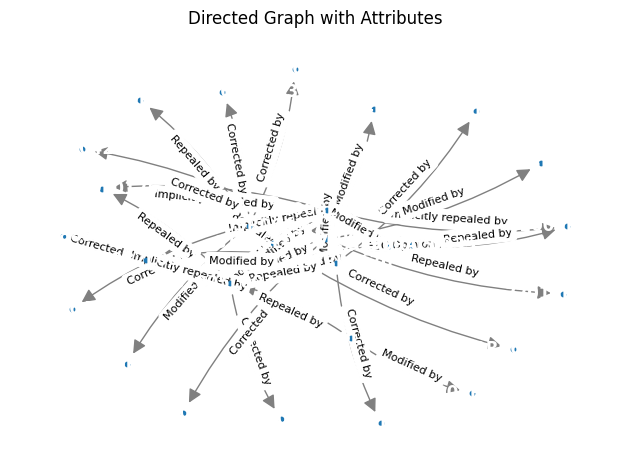

In [ ]:
# it takes 2m to get the full graph from the modifies talbe in the url3
from graph_builder import Modifies
ms2 = Modifies(url4)

print(ms2.first_url)
print(ms2.attributes_list)   # comes from GraphBuilder
print(ms2.G)                 # should exist
print(ms2.modifies_links)
print(ms2.document)
urls2 = ms2.collect_all_urls()
graph2 = ms2.generate_full_graph(urls2, visualize = True)

Select the relevent links from the arguments 
(relations=[], acts=[], comments=[], subdivisions=[], froms=[], tos=[]):

In [ ]:
#6 mintues Even though there are 6 links collected (input link + 5 corrected by links), among them only the input link contains 'corrected by'. So the output graph is the same.
from graph_builder import Modifiedby
mb1 = Modifiedby("https://eur-lex.europa.eu/legal-content/EN/TXT/?uri=CELEX:32019R2019")
selected_urls1 = mb1.collect_selected_urls(relations=['Corrected by'])
graph_1 = mb1.generate_full_graph(selected_urls1, visualize = True)

Crawling URLs: 1it [00:09,  9.14s/it]



Total URLs collected: 1


Building graph: 100%|██████████| 1/1 [00:06<00:00,  6.06s/it]


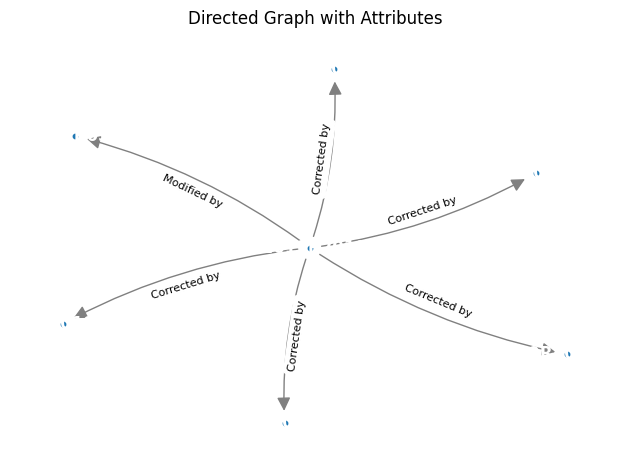

In [3]:
# when the total url returns 1 link, which means the link is the input link.
from graph_builder import Modifies
ms1 = Modifies(url3)
selected_urls2 = ms1.collect_selected_urls(relations=['Corrected by'])
graph1 = ms1.generate_full_graph(selected_urls2, visualize = True)